<h1>Squential Graph</h1>

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    name : str
    age :  str
    final : str

In [7]:
def first_node(state:AgentState)-> AgentState:
    """ This is the first node of our sequence """

    state['final'] = f"Hi {state['name']}"
    return state

def second_node(state:AgentState)-> AgentState:
    """ This is the second node of our sequence """

    state['final'] =state['final'] + f", your age is {state['age']}"
    return state

In [8]:
graph = StateGraph(AgentState)

graph.add_node("first_node",first_node)
graph.add_node("second_node",second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")

app = graph.compile()

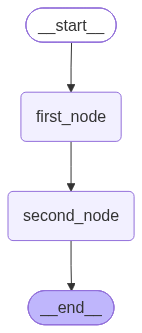

In [9]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
result = app.invoke({"name":"Charlie","age":20})
result

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie, your age is 20'}